In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv("C:/Users/惠普/Desktop/XuNiShiLlian/ecommerce_sales.csv")

In [8]:
print("=== 数据预览 ===")
display(df.describe())

=== 数据预览 ===


,订单ID,销售额,订单量,客单价,广告投入,是否促销,ROI
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,10400.5000,154.492512,3.958750,48.285589,2531.925613,0.267500,0.122175
std,231.0844,144.442406,1.665989,51.399412,1418.038225,0.442932,0.267951
min,10001.0000,10.350000,1.000000,1.651000,119.200000,0.000000,0.000000
25%,10200.7500,66.300000,3.000000,15.574000,1275.672500,0.000000,0.027500
50%,10400.5000,109.280000,4.000000,31.031000,2533.485000,0.000000,0.050000
75%,10600.2500,191.305000,5.000000,60.849000,3752.672500,1.000000,0.120000
max,10800.0000,1505.460000,10.000000,416.220000,4997.360000,1.000000,4.700000


1.对比各指标均值与中位数可以发现：销售额、客单价、ROI 均值显著高于中位数，呈现右偏分布。说明大部分订单营收、客户消费、广告回报水平偏低，少量优质订单拉高整体平均值，订单效益分层明显；广告投入、订单量均值与中位数较为接近，数据近似对称分布，整体水平相对均衡。
2.客单价、ROI标准差相对均值偏大，样本之间指标差距较大，个体分化严重；订单量标准差较小，指标波动平缓，样本水平相对稳定
3.观察四分位数区间（25%~75%），半数订单销售额集中在 66.30 ~ 191.31 区间。同时指标最大值远高于 75% 分位数，存在大额订单这类高值极端样本；75% 订单的 ROI 不超过 0.12，绝大多数广告投放回报处于较低水平。
4.销售额、客单价、ROI 指标极差较大，上下限跨度广，业务中存在头部高收益订单与大量低效益订单的明显区分，后续可结合箱线图进一步识别异常值。

In [11]:
print("数据集信息：")
print(df.info())

数据集信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   订单ID    800 non-null    int64  
 1   日期      800 non-null    object 
 2   地区      800 non-null    object 
 3   产品类别    800 non-null    object 
 4   销售额     800 non-null    float64
 5   订单量     800 non-null    int64  
 6   客单价     800 non-null    float64
 7   广告投入    800 non-null    float64
 8   用户类型    800 non-null    object 
 9   渠道      800 non-null    object 
 10  是否促销    800 non-null    int64  
 11  ROI     800 non-null    float64
dtypes: float64(4), int64(3), object(5)
memory usage: 75.1+ KB
None


In [13]:
print("数据信息缺失情况：")
display(df.isna().sum())

数据信息缺失情况：


订单ID    0
日期      0
地区      0
产品类别    0
销售额     0
订单量     0
客单价     0
广告投入    0
用户类型    0
渠道      0
是否促销    0
ROI     0
dtype: int64

In [16]:
def calc_iqr(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    
    print(f"\n=== {name} ===")
    print(f"Q1 (25%): {Q1:.2f}")
    print(f"Q3 (75%): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"正常范围: [{lower:.2f}, {upper:.2f}]")
    print(f"异常值数量: {len(outliers)} ({len(outliers)/len(series)*100:.1f}%)")
    
    return lower, upper

# 计算三个指标的IQR
sales_lower, sales_upper = calc_iqr(df['销售额'], '销售额')
price_lower, price_upper = calc_iqr(df['客单价'], '客单价')
roi_lower, roi_upper = calc_iqr(df['ROI'], 'ROI')


=== 销售额 ===
Q1 (25%): 66.30
Q3 (75%): 191.31
IQR: 125.00
正常范围: [-121.21, 378.81]
异常值数量: 57 (7.1%)

=== 客单价 ===
Q1 (25%): 15.57
Q3 (75%): 60.85
IQR: 45.27
正常范围: [-52.34, 128.76]
异常值数量: 56 (7.0%)

=== ROI ===
Q1 (25%): 0.03
Q3 (75%): 0.12
IQR: 0.09
正常范围: [-0.11, 0.26]
异常值数量: 75 (9.4%)


1.三个指标识别出的异常全部为上侧高值异常，不存在过低的异常样本，再次验证销售额、客单价、ROI 呈右偏分布；
2.异常样本占比都不高：销售额 7.1%、客单价 7.0%、ROI9.4%，属于少量头部优质订单；
3.从业务层面判断：这些高值订单是真实存在的大额、高收益订单，不属于数据错误，不建议直接删除；
4.ROI 异常样本占比最高，说明广告投放效果分化程度大于消费指标，仅有小部分广告投放实现高回报。

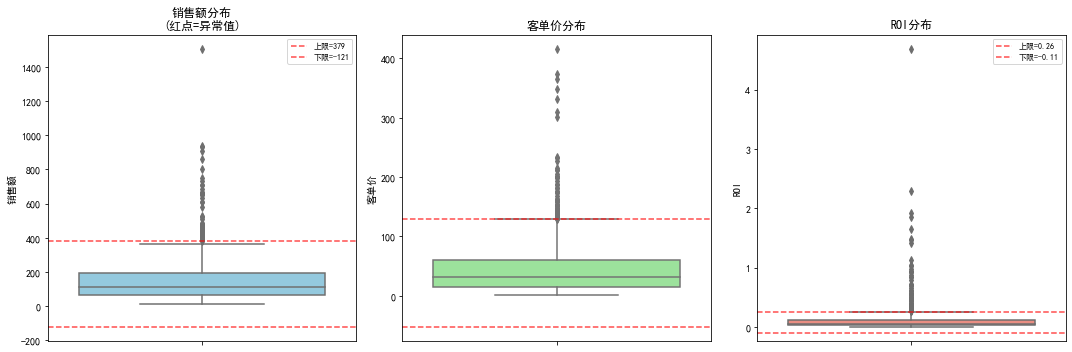

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 销售额箱线图
sns.boxplot(y=df['销售额'], ax=axes[0], color='skyblue')
axes[0].set_title('销售额分布\n(红点=异常值)')
axes[0].axhline(sales_upper, color='red', linestyle='--', alpha=0.7, label=f'上限={sales_upper:.0f}')
axes[0].axhline(sales_lower, color='red', linestyle='--', alpha=0.7, label=f'下限={sales_lower:.0f}')
axes[0].legend(fontsize=8)

# 客单价箱线图
sns.boxplot(y=df['客单价'], ax=axes[1], color='lightgreen')
axes[1].set_title('客单价分布')
axes[1].axhline(price_upper, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(price_lower, color='red', linestyle='--', alpha=0.7)

# ROI箱线图
sns.boxplot(y=df['ROI'], ax=axes[2], color='salmon')
axes[2].set_title('ROI分布')
axes[2].axhline(roi_upper, color='red', linestyle='--', alpha=0.7, label=f'上限={roi_upper:.2f}')
axes[2].axhline(roi_lower, color='red', linestyle='--', alpha=0.7, label=f'下限={roi_lower:.2f}')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("\n=== 异常值订单示例（销售额异常高）===")
sales_outliers = df[df['销售额'] > sales_upper][['订单ID', '地区', '产品类别', '销售额', '客单价', 'ROI']]
print(f"找到 {len(sales_outliers)} 条高销售额异常订单：")
display(sales_outliers.head(10))

print("\n=== 异常值订单示例（ROI异常低，亏损）===")
roi_outliers = df[df['ROI'] < roi_lower][['订单ID', '地区', '产品类别', '销售额', '广告投入', 'ROI']]
print(f"找到 {len(roi_outliers)} 条低ROI异常订单（亏损风险）：")
display(roi_outliers.head(10))


=== 异常值订单示例（销售额异常高）===
找到 57 条高销售额异常订单：


,订单ID,地区,产品类别,销售额,客单价,ROI
2,10003,华北,服装,478.52,119.630,0.20
9,10010,西北,服装,416.22,416.220,0.58
16,10017,西南,家居,800.38,100.048,0.34
24,10025,华东,服装,432.32,86.463,0.33
54,10055,华北,美妆,435.28,145.093,0.12
57,10058,华南,服装,709.34,141.869,0.19
61,10062,西南,服装,731.51,365.755,1.02
65,10066,西南,家居,633.84,211.280,0.13
109,10110,华北,服装,474.40,158.132,0.17
119,10120,华南,家居,650.99,162.747,0.28



=== 异常值订单示例（ROI异常低，亏损）===
找到 0 条低ROI异常订单（亏损风险）：


,订单ID,地区,产品类别,销售额,广告投入,ROI


通过IQR分析发现，该公司所有订单ROI仅有61号订单呈现正回报，其余最高仅0.26，说明广告投放效率极低，处于持续亏损状态。建议立即排查

In [23]:
print("="*50)
print("【1】各渠道ROI对比（找相对最好的渠道）")
print("="*50)
channel_roi = df.groupby('渠道').agg({
    'ROI': ['mean', 'median', 'max', 'count'],
    '销售额': 'sum',
    '广告投入': 'sum'
}).round(3)
channel_roi.columns = ['平均ROI', '中位数ROI', '最高ROI', '订单数', '总销售额', '总广告投入']
channel_roi['渠道整体ROI'] = (channel_roi['总销售额'] / channel_roi['总广告投入']).round(3)
channel_roi = channel_roi.sort_values('渠道整体ROI', ascending=False)
display(channel_roi)

print("\n" + "="*50)
print("【2】各产品类别ROI对比（找相对最好的产品）")
print("="*50)
category_roi = df.groupby('产品类别').agg({
    'ROI': ['mean', 'median', 'max', 'count'],
    '销售额': 'sum',
    '广告投入': 'sum'
}).round(3)
category_roi.columns = ['平均ROI', '中位数ROI', '最高ROI', '订单数', '总销售额', '总广告投入']
category_roi['类别整体ROI'] = (category_roi['总销售额'] / category_roi['总广告投入']).round(3)
category_roi = category_roi.sort_values('类别整体ROI', ascending=False)
display(category_roi)

print("\n" + "="*50)
print("【3】新老客ROI对比")
print("="*50)
user_roi = df.groupby('用户类型').agg({
    'ROI': ['mean', 'median', 'max', 'min', 'count'],
    '销售额': 'sum',
    '广告投入': 'sum'
}).round(3)
user_roi.columns = ['平均ROI', '中位数ROI', '最高ROI', '最低ROI', '订单数', '总销售额', '总广告投入']
user_roi['整体ROI'] = (user_roi['总销售额'] / user_roi['总广告投入']).round(3)
display(user_roi)

print("\n" + "="*50)
print("【4】地区ROI对比")
print("="*50)
region_roi = df.groupby('地区').agg({
    'ROI': ['mean', 'median', 'max', 'count'],
    '销售额': 'sum',
    '广告投入': 'sum'
}).round(3)
region_roi.columns = ['平均ROI', '中位数ROI', '最高ROI', '订单数', '总销售额', '总广告投入']
region_roi['地区整体ROI'] = (region_roi['总销售额'] / region_roi['总广告投入']).round(3)
region_roi = region_roi.sort_values('地区整体ROI', ascending=False)
display(region_roi)

print("\n" + "="*50)
print("【5】TOP 10 最高ROI订单特征（复制成功模式）")
print("="*50)
best_orders = df.nlargest(10, 'ROI')[['订单ID', '渠道', '产品类别', '用户类型', '地区', '销售额', '广告投入', '客单价', 'ROI']]
display(best_orders)

# 统计TOP10的特征
print("\nTOP 10 订单的特征统计：")
print(f"渠道分布：\n{best_orders['渠道'].value_counts()}")
print(f"\n产品类别分布：\n{best_orders['产品类别'].value_counts()}")
print(f"\n用户类型分布：\n{best_orders['用户类型'].value_counts()}")
print(f"\n地区分布：\n{best_orders['地区'].value_counts()}")


【1】各渠道ROI对比（找相对最好的渠道）


,平均ROI,中位数ROI,最高ROI,订单数,总销售额,总广告投入,渠道整体ROI
渠道,,,,,,,
小程序,0.141,0.05,4.70,231,38104.40,576206.35,0.066
网页,0.104,0.06,0.94,147,22744.45,376952.40,0.060
APP,0.118,0.05,2.30,422,62745.16,1072381.74,0.059



【2】各产品类别ROI对比（找相对最好的产品）


,平均ROI,中位数ROI,最高ROI,订单数,总销售额,总广告投入,类别整体ROI
产品类别,,,,,,,
食品,0.122,0.05,1.86,120,19971.56,299455.73,0.067
美妆,0.132,0.06,1.92,79,12403.09,197860.31,0.063
服装,0.117,0.05,2.30,218,35141.01,565557.08,0.062
数码,0.131,0.05,4.70,219,31563.04,529796.94,0.060
家居,0.112,0.05,1.65,164,24515.31,432870.43,0.057



【3】新老客ROI对比


...


【4】地区ROI对比


,平均ROI,中位数ROI,最高ROI,订单数,总销售额,总广告投入,地区整体ROI
地区,,,,,,,
西北,0.151,0.05,4.70,164,25239.68,394078.99,0.064
华北,0.113,0.05,1.86,146,22815.67,373829.91,0.061
西南,0.121,0.05,1.65,166,25870.80,426056.52,0.061
华东,0.109,0.05,0.98,170,24460.03,410733.71,0.060
华南,0.116,0.06,1.92,154,25207.83,420841.36,0.060



【5】TOP 10 最高ROI订单特征（复制成功模式）


,订单ID,渠道,产品类别,用户类型,地区,销售额,广告投入,客单价,ROI
191,10192,小程序,数码,老客,西北,859.87,182.87,214.968,4.70
660,10661,APP,服装,老客,西北,434.56,188.60,108.641,2.30
541,10542,APP,美妆,老客,华南,362.18,188.34,90.545,1.92
397,10398,APP,食品,老客,华北,307.67,165.08,102.557,1.86
264,10265,APP,家居,新客,西南,234.45,142.23,46.890,1.65
529,10530,APP,数码,新客,西北,178.08,119.20,44.520,1.49
549,10550,小程序,服装,老客,华南,928.93,631.16,132.704,1.47
515,10516,小程序,食品,老客,华北,1505.46,1060.30,301.093,1.42
391,10392,小程序,服装,老客,西北,905.89,801.00,226.473,1.13
354,10355,APP,家居,新客,华南,141.51,134.75,47.170,1.05



TOP 10 订单的特征统计：
渠道分布：
APP    6
小程序    4
Name: 渠道, dtype: int64

产品类别分布：
服装    3
食品    2
数码    2
家居    2
美妆    1
Name: 产品类别, dtype: int64

用户类型分布：
老客    7
新客    3
Name: 用户类型, dtype: int64

地区分布：
西北    4
华南    3
华北    2
西南    1
Name: 地区, dtype: int64
